In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

# 딥러닝: 데이터의 규칙성을 추출
- 응용분야 : 글씨인식, 문장분류, 값예측, 질병진단, 얼굴
    * 지도학습(입력=독립변수, 타겟 = 종속변수)
        * 분류분석(타겟변수가 category변수인 분석, 다중분류와 이진분류) vs 회귀분석
    * 비지도학습(입력변수)
        * 군집화
    * 강화학습

- 지도학습에서의 딥러닝 프로그래밍 방식
    - 1. 데이터 확보
    - 2. 데이터 전처리 : 스케일 조정,인코딩처리(라벨인코딩, 원핫인코딩), 학습, 검증, 시험데이터셋 분리
    - 3. 모델 구성
    - 4. 모델 학습 과정 설정
    - 5. 모델 학습시키기(훈련, 검증 데이터셋)
    - 6. 모델 평가(시험 데이터셋)
    - 7. 모델 저장/사용(입력값이 주어지면 예측값을 받기)
    

In [7]:
from tensorflow.keras.utils import to_categorical # 분류 분석시 원핫인코딩(추천)
import pandas as pd #원핫인코딩
from tensorflow.keras.models import Sequential, load_model, save_model # 모델 생성, 모델 load
from tensorflow.keras.layers import Dense, Input # 모델에 층을 쌓기 위해서
import numpy as np

# 1. 데이터셋 확보
# 2. 데이터 전처리

In [31]:
# 학습데이터 = 훈련데이터셋
x_train = np.array([1,2,3,4,5,6,7,8,9]*10)
y_train = np.array([2,3,4,5,6,7,8,9,10]*10)
# 검증데이터, 시험데이터셋
x_val = np.array([1,2,3,4,5,6,7,8,9])
y_val = np.array([2,3,4,5,6,7,8,9,10])


In [29]:
# 인코딩 종류
    # 라벨인코딩 = 문자를 숫자로
    # 원핫인코딩 = 값의 갯수만큼 열을 만들고,해당 범주에 해당하는 열만 1을, 나머지 열은 0을 넣는 방법
data= np.array(['aa','bb','ff','bb','df'])
print('원데이터:',data)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# le.fit(data)
# labeling_data = le.transform(data)
labeling_data= le.fit_transform(data)  # fit과 transform을 한번에하는 함수
print('라벨인코딩된 데이터:', labeling_data)
onehot_encoding_data=to_categorical(labeling_data)
print('원핫인코딩된 데이터: \n', onehot_encoding_data)   # array 배열로 출력
# 원핫인코딩은 라벨인코딩 생성후 생성가능

#두번째 방법
onehot_encoding_data2= pd.get_dummies(data)
print('원핫인코딩된 데이터: \n', onehot_encoding_data2)   #dataframe 으로 출력

원데이터: ['aa' 'bb' 'ff' 'bb' 'df']
라벨인코딩된 데이터: [0 1 3 1 2]
원핫인코딩된 데이터: 
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]
원핫인코딩된 데이터: 
    aa  bb  df  ff
0   1   0   0   0
1   0   1   0   0
2   0   0   0   1
3   0   1   0   0
4   0   0   1   0


In [28]:
data= np.array([1,4,5,4,5])
categorical_onehot = to_categorical(data)
print('to_categorical 이용 \n', categorical_onehot)
getdummies_onehot=pd.get_dummies(data)
print('get_dummies 이용 \n', getdummies_onehot)

to_categorical 이용 
 [[0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]]
get_dummies 이용 
    1  4  5
0  1  0  0
1  0  1  0
2  0  0  1
3  0  1  0
4  0  0  1


In [36]:
# 분류분석을 위한 종속(타겟)변수의 원핫인코딩
Y_train=to_categorical(y_train,11)
Y_val=to_categorical(y_val)

In [38]:
# 딥러닝 모델에 사용될 데이터
x_train.shape, Y_train.shape, x_val.shape, Y_val.shape

((90,), (90, 11), (9,), (9, 11))

In [39]:
Y_val[0]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

# 3. 모델 구성

In [40]:
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(units=38, activation='sigmoid')) #relu, elu, tanh, sigmoid, softmax
#activation function(활성화함수),그대로 보내지않고 선별해서 과접합 데이터가 넘어가는걸 방지 
model.add(Dense(64,activation='elu'))
model.add(Dense(32,activation='elu'))
model.add(Dense(11,activation='softmax')) # 다중분류에서의 출력층 활성화 함수 : softmax
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 38)                76        
                                                                 
 dense_1 (Dense)             (None, 64)                2496      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 11)                363       
                                                                 
Total params: 5,015
Trainable params: 5,015
Non-trainable params: 0
_________________________________________________________________


# 4. 모델학습과정 설정
- 회귀분석에서의 loss : mse, mae, rmse
- 다중 분류에서의 loss : categorical_crossentropy
- 이진 분류에서의 loss : binary_crossentropy
- 분류분석에서의 metrics(평가지표) : accuracy, recall, precision

In [42]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam', 
              metrics=['accuracy'])

# 5. 모델학습시키기

In [43]:
hist = model.fit(x_train,Y_train,  #학습데이터셋(입력변수와 타겟변수)
                 epochs=300, #학습횟수
                 batch_size=10,
                 validation_data=(x_val, Y_val),
                 verbose=1)
#verbose=0 : 학습로그출력없음/ 1:기본값출력 / 2:자세한로그출력



Epoch 1/300
9/9 [==============================] - 1s 41ms/step - loss: 2.3329 - accuracy: 0.1000 - val_loss: 2.2347 - val_accuracy: 0.1111
Epoch 2/300
9/9 [==============================] - 0s 6ms/step - loss: 2.2120 - accuracy: 0.1333 - val_loss: 2.1582 - val_accuracy: 0.2222
Epoch 3/300
9/9 [==============================] - 0s 6ms/step - loss: 2.1420 - accuracy: 0.2556 - val_loss: 2.1053 - val_accuracy: 0.3333
Epoch 4/300
9/9 [==============================] - 0s 6ms/step - loss: 2.0923 - accuracy: 0.2889 - val_loss: 2.0565 - val_accuracy: 0.2222
Epoch 5/300
9/9 [==============================] - 0s 6ms/step - loss: 2.0414 - accuracy: 0.2222 - val_loss: 2.0054 - val_accuracy: 0.2222
Epoch 6/300
9/9 [==============================] - 0s 5ms/step - loss: 1.9947 - accuracy: 0.2556 - val_loss: 1.9539 - val_accuracy: 0.2222
Epoch 7/300
9/9 [==============================] - 0s 5ms/step - loss: 1.9486 - accuracy: 0.2667 - val_loss: 1.8989 - val_accuracy: 0.3333
Epoch 8/300
9/9 [=========

9/9 [==============================] - 0s 5ms/step - loss: 0.4536 - accuracy: 0.9222 - val_loss: 0.4359 - val_accuracy: 1.0000
Epoch 60/300
9/9 [==============================] - 0s 6ms/step - loss: 0.4461 - accuracy: 1.0000 - val_loss: 0.4290 - val_accuracy: 1.0000
Epoch 61/300
9/9 [==============================] - 0s 6ms/step - loss: 0.4266 - accuracy: 0.9667 - val_loss: 0.4172 - val_accuracy: 1.0000
Epoch 62/300
9/9 [==============================] - 0s 5ms/step - loss: 0.4241 - accuracy: 0.9111 - val_loss: 0.4002 - val_accuracy: 0.8889
Epoch 63/300
9/9 [==============================] - 0s 5ms/step - loss: 0.3948 - accuracy: 0.9889 - val_loss: 0.3893 - val_accuracy: 1.0000
Epoch 64/300
9/9 [==============================] - 0s 6ms/step - loss: 0.3911 - accuracy: 1.0000 - val_loss: 0.3733 - val_accuracy: 1.0000
Epoch 65/300
9/9 [==============================] - 0s 6ms/step - loss: 0.3762 - accuracy: 1.0000 - val_loss: 0.3632 - val_accuracy: 1.0000
Epoch 66/300
9/9 [===============

9/9 [==============================] - 0s 6ms/step - loss: 0.0731 - accuracy: 1.0000 - val_loss: 0.0704 - val_accuracy: 1.0000
Epoch 118/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0710 - accuracy: 1.0000 - val_loss: 0.0683 - val_accuracy: 1.0000
Epoch 119/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0686 - accuracy: 1.0000 - val_loss: 0.0657 - val_accuracy: 1.0000
Epoch 120/300
9/9 [==============================] - 0s 5ms/step - loss: 0.0654 - accuracy: 1.0000 - val_loss: 0.0635 - val_accuracy: 1.0000
Epoch 121/300
9/9 [==============================] - 0s 5ms/step - loss: 0.0660 - accuracy: 1.0000 - val_loss: 0.0625 - val_accuracy: 1.0000
Epoch 122/300
9/9 [==============================] - 0s 5ms/step - loss: 0.0652 - accuracy: 1.0000 - val_loss: 0.0633 - val_accuracy: 1.0000
Epoch 123/300
9/9 [==============================] - 0s 5ms/step - loss: 0.0624 - accuracy: 1.0000 - val_loss: 0.0632 - val_accuracy: 1.0000
Epoch 124/300
9/9 [========

9/9 [==============================] - 0s 5ms/step - loss: 0.0167 - accuracy: 1.0000 - val_loss: 0.0162 - val_accuracy: 1.0000
Epoch 176/300
9/9 [==============================] - 0s 6ms/step - loss: 0.0163 - accuracy: 1.0000 - val_loss: 0.0159 - val_accuracy: 1.0000
Epoch 177/300
9/9 [==============================] - 0s 6ms/step - loss: 0.0159 - accuracy: 1.0000 - val_loss: 0.0156 - val_accuracy: 1.0000
Epoch 178/300
9/9 [==============================] - 0s 6ms/step - loss: 0.0155 - accuracy: 1.0000 - val_loss: 0.0152 - val_accuracy: 1.0000
Epoch 179/300
9/9 [==============================] - 0s 5ms/step - loss: 0.0152 - accuracy: 1.0000 - val_loss: 0.0149 - val_accuracy: 1.0000
Epoch 180/300
9/9 [==============================] - 0s 6ms/step - loss: 0.0149 - accuracy: 1.0000 - val_loss: 0.0146 - val_accuracy: 1.0000
Epoch 181/300
9/9 [==============================] - 0s 5ms/step - loss: 0.0148 - accuracy: 1.0000 - val_loss: 0.0144 - val_accuracy: 1.0000
Epoch 182/300
9/9 [========

9/9 [==============================] - 0s 6ms/step - loss: 0.0063 - accuracy: 1.0000 - val_loss: 0.0062 - val_accuracy: 1.0000
Epoch 234/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0062 - accuracy: 1.0000 - val_loss: 0.0061 - val_accuracy: 1.0000
Epoch 235/300
9/9 [==============================] - 0s 5ms/step - loss: 0.0061 - accuracy: 1.0000 - val_loss: 0.0060 - val_accuracy: 1.0000
Epoch 236/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0060 - accuracy: 1.0000 - val_loss: 0.0059 - val_accuracy: 1.0000
Epoch 237/300
9/9 [==============================] - 0s 6ms/step - loss: 0.0060 - accuracy: 1.0000 - val_loss: 0.0058 - val_accuracy: 1.0000
Epoch 238/300
9/9 [==============================] - 0s 6ms/step - loss: 0.0058 - accuracy: 1.0000 - val_loss: 0.0058 - val_accuracy: 1.0000
Epoch 239/300
9/9 [==============================] - 0s 6ms/step - loss: 0.0058 - accuracy: 1.0000 - val_loss: 0.0057 - val_accuracy: 1.0000
Epoch 240/300
9/9 [========

9/9 [==============================] - 0s 5ms/step - loss: 0.0030 - accuracy: 1.0000 - val_loss: 0.0030 - val_accuracy: 1.0000
Epoch 292/300
9/9 [==============================] - 0s 5ms/step - loss: 0.0030 - accuracy: 1.0000 - val_loss: 0.0030 - val_accuracy: 1.0000
Epoch 293/300
9/9 [==============================] - 0s 6ms/step - loss: 0.0030 - accuracy: 1.0000 - val_loss: 0.0030 - val_accuracy: 1.0000
Epoch 294/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0030 - accuracy: 1.0000 - val_loss: 0.0029 - val_accuracy: 1.0000
Epoch 295/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0029 - accuracy: 1.0000 - val_loss: 0.0029 - val_accuracy: 1.0000
Epoch 296/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0029 - accuracy: 1.0000 - val_loss: 0.0029 - val_accuracy: 1.0000
Epoch 297/300
9/9 [==============================] - 0s 6ms/step - loss: 0.0029 - accuracy: 1.0000 - val_loss: 0.0028 - val_accuracy: 1.0000
Epoch 298/300
9/9 [========

# 6. 모델평가하기(모델 학습과정 살펴보고 evaluate)

In [44]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

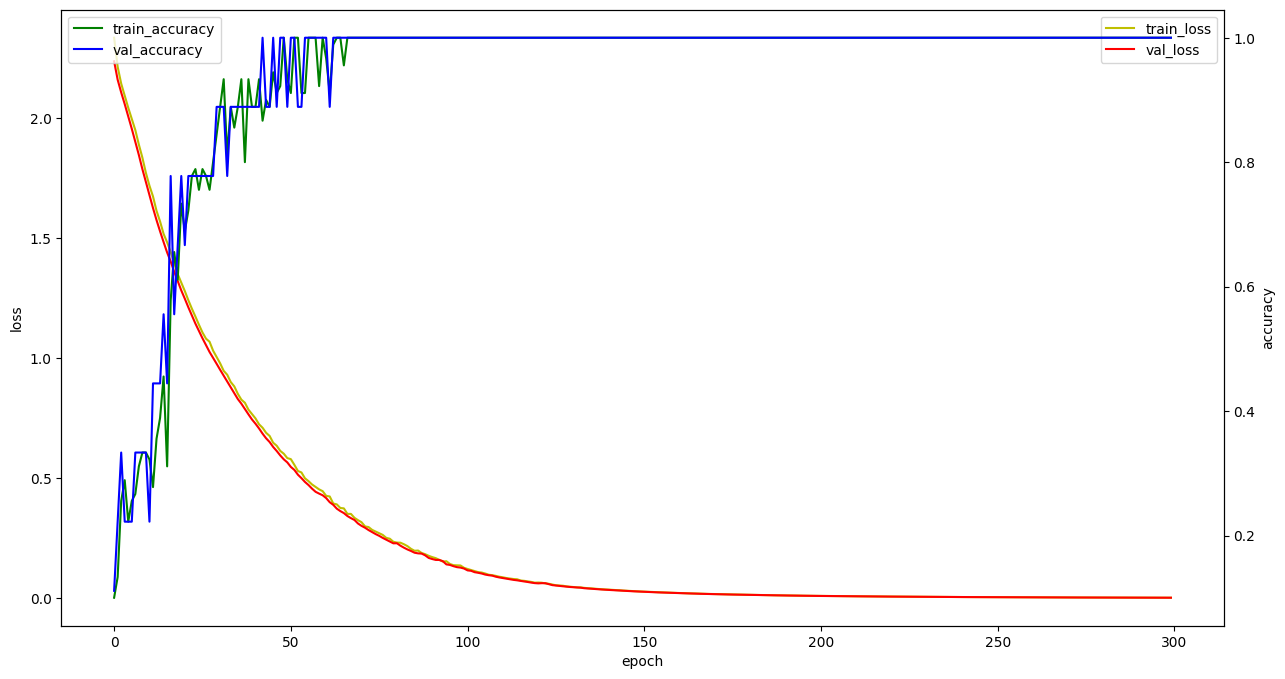

In [61]:
# 학습과정 살펴보기
import matplotlib.pyplot as plt
fig, loss_ax=plt.subplots(figsize=(15,8))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax=loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')

loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend()
acc_ax.legend()

In [63]:
# 모델 평가하기
score =model.evaluate(x_val, Y_val,batch_size=3)
print('loss: ', score[0])
print('accuracy: ', score[1])

3/3 [==============================] - 0s 2ms/step - loss: 0.0027 - accuracy: 1.0000
loss:  0.002741701900959015
accuracy:  1.0


# 7. 모델 저장 및 사용

In [65]:
model.save('model/02_deep.h5') # 모델 저장 파일 : h5 이나 keras(tensorflow 2.14이후버전)

In [66]:
# 저장된 모델 사용하기
model1=load_model('model/02_deep.h5')

In [70]:
# 모델 사용
h=model.predict(np.array([5]))
h.argmax()

1/1 [==============================] - 0s 33ms/step


6

In [71]:
model.predict(np.array([2])).argmax()

1/1 [==============================] - 0s 41ms/step


3

In [73]:
# 몇 %확률로 5로 예측했나?
h[0,h.argmax()]*100

99.73567724227905

In [76]:
h[0,[5,6,7]]

array([8.5291883e-04, 9.9735677e-01, 1.7902540e-03], dtype=float32)